# Lentils foreign-object segmentation with DynUNet — inference

Loads a trained artifact (the [`01_train.ipynb`](01_train.ipynb) output by default; point
`LENTILS_PIPELINE_DIR` at a `train.py` run to evaluate a champion reproduction instead),
restores it with `CuvisPipeline.load_pipeline`, and

1. evaluates the test split — pixel **fg-IoU / fg-Dice** on object frames plus **image-level
   AUROC** (max foreground probability vs the frame-has-objects label) over all frames, and
2. renders per-frame overlays: false-color RGB, foreground probability, prediction vs GT.

At inference the graph runs only `Norm → DynUNet` (the losses are train/val/test-gated and the
augmentation is an identity passthrough); DynUNet tiles each full frame with Gaussian-blended
overlaps. `tile_batch=16` packs tiles onto the batch axis (~16× faster on the 2D mode,
output-identical).

In [1]:
import utils

cfg = utils.resolve_config()
yaml_path, pt_path = utils.resolve_pipeline()
print("artifact:", yaml_path)

eng = utils.import_engine()
registry = eng.register_plugins(cfg["unet_manifest"], cfg["augment_manifest"])
pipe = eng.load_artifact(yaml_path, pt_path, registry=registry)
print("restored nodes:", [n.name for n in pipe.nodes])

artifact: /mnt/data/anish/cuvis-ai-unet/notebooks/lentils_segmentation/outputs/unet2d/pipeline.yaml


2026-07-16 07:33:45.691 | DEBUG    | cuvis_ai_core.utils.git_and_os:import_plugin_nodes:196 - Imported plugin node 'DynUNet' from 'cuvis_ai_unet.node.dynunet.DynUNet'


2026-07-16 07:33:45.692 | DEBUG    | cuvis_ai_core.utils.git_and_os:import_plugin_nodes:196 - Imported plugin node 'DiceLoss' from 'cuvis_ai_unet.node.losses.DiceLoss'


2026-07-16 07:33:45.692 | DEBUG    | cuvis_ai_core.utils.git_and_os:import_plugin_nodes:196 - Imported plugin node 'CrossEntropyLoss' from 'cuvis_ai_unet.node.losses.CrossEntropyLoss'


2026-07-16 07:33:45.692 | DEBUG    | cuvis_ai_core.utils.node_registry:_register_node_classes:482 - Registered plugin node 'DynUNet' from 'unet'


...

2026-07-16 07:33:45.696 | DEBUG    | cuvis_ai_core.utils.node_registry:_register_node_classes:482 - Registered plugin node 'AugmentationCompose' from 'augment'


2026-07-16 07:33:45.696 | INFO     | cuvis_ai_core.utils.node_registry:register_plugins_installed:534 - Loaded preinstalled plugin 'augment' with 1 nodes


2026-07-16 07:33:45.696 | INFO     | cuvis_ai_core.utils.node_registry:register_plugin:380 - Registered plugin 'augment' from /mnt/data/anish/cuvis-ai-unet/examples/lentils/augment.yaml


restored nodes: ['DataSource', 'Norm', 'Augment', 'DynUNet', 'DiceLoss', 'CrossEntropyLoss']


/mnt/data/anish/cuvis-ai/.venv/lib/python3.11/site-packages/cuvis_ai_core/pipeline/factory.py:238: MissingNodeMetadataWarning: Node class cuvis_ai_augment.node.compose.AugmentationCompose is missing explicit _category and _tags. Declare on the class body, e.g.:
    _category = NodeCategory.TRANSFORM  # graph role: SOURCE / SINK / TRANSFORM / MODEL / LOSS / METRIC / REGULARIZER / OPTIMIZER / SCHEDULER / RUNNER / CONTROL / VISUALIZER
    _tags = frozenset({NodeTag.HYPERSPECTRAL, NodeTag.PREPROCESSING})  # any modality / task / lifecycle / property / backend tags that apply
  pipeline._assign_counter_and_add_node(node)


## Evaluate

The tutorial artifact was trained on a few frames for a few epochs, so its numbers sit far below the champion reference — the comparison line shows the gap. The demo evaluates a small class-balanced subset; a full evaluation runs `eng.evaluate(..., max_frames=0)` on the whole 180-frame test split with a champion-scale artifact.


In [2]:
import csv as _csv

import numpy as np

splits_csv = (
    utils.LENTILS_NPZ_OUT / "lentils_seg_splits_fromhf.csv"
    if cfg["data_source"] == "hf"
    else cfg["splits_csv"]
)


def _has_object(npz_path):
    # npz is lazy: reading only "mask" never touches the ~263 MB cube.
    with np.load(npz_path) as z:
        return "mask" in z.files and bool(np.asarray(z["mask"]).any())


# A small, class-balanced demo subset so the metrics are meaningful. A full
# evaluation is `max_frames=0` on the whole test split (slow on CPU for a deep
# net); the tutorial artifact is tiny so its numbers sit far below the champion.
test_frames = eng.split_frames(splits_csv, "test")
objs = [p for p in test_frames if _has_object(p)]
norms = [p for p in test_frames if p not in set(objs)]
demo = objs[:4] + norms[:4]
rows = [
    r
    for r in _csv.DictReader(open(splits_csv))
    if r["split"] == "test" and r["npz_path"] in set(demo)
]
demo_csv = "outputs/demo_test_subset.csv"
with open(demo_csv, "w", newline="") as f:
    w = _csv.DictWriter(f, fieldnames=["split", "npz_path", "image_id"])
    w.writeheader()
    w.writerows(rows)

metrics = eng.evaluate(pipe, demo_csv, split="test", max_frames=0)
champ = utils.CHAMPION["2d_128"]
print(
    f"demo subset: {metrics['frames']} frames "
    f"({metrics['object_frames']} object / {metrics['normal_frames']} normal)\n"
    f"fg-IoU  = {metrics['fg_iou']:.4f}   (champion {champ['fg_iou']:.4f})\n"
    f"fg-Dice = {metrics['fg_dice']:.4f}   (champion {champ['fg_dice']:.4f})\n"
    f"image-AUROC (max-prob) = {metrics['image_auroc_maxprob']:.4f}   "
    f"(champion {champ['image_auroc']:.3f})"
)


demo subset: 8 frames (4 object / 4 normal)
fg-IoU  = 0.0000   (champion 0.7905)
fg-Dice = 0.0000   (champion 0.8787)
image-AUROC (max-prob) = 1.0000   (champion 0.998)


## Visualize predictions

The two-node inference path, spelled out: z-score the full frame, tile it through DynUNet,
softmax the logits into a foreground-probability map, and argmax into a predicted mask.

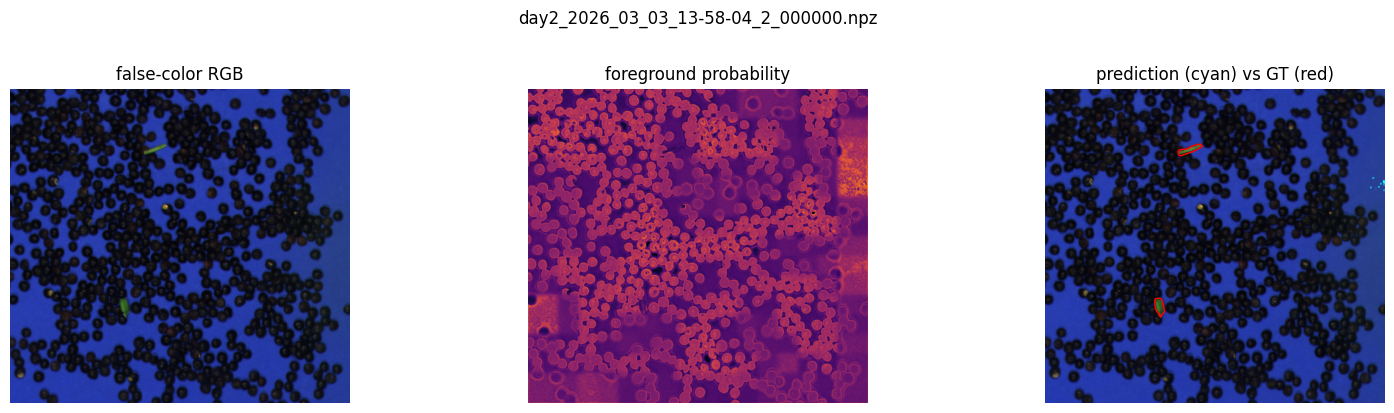

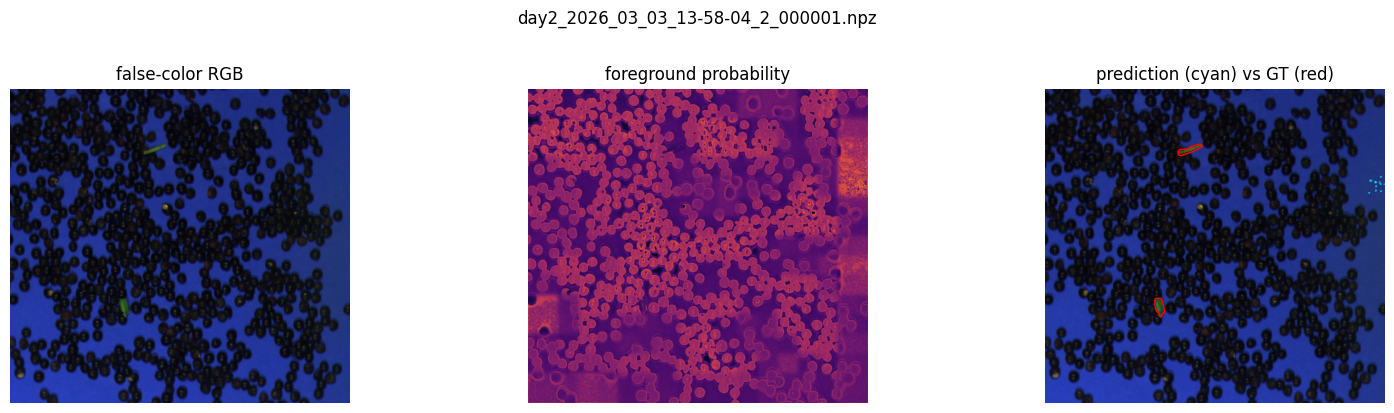

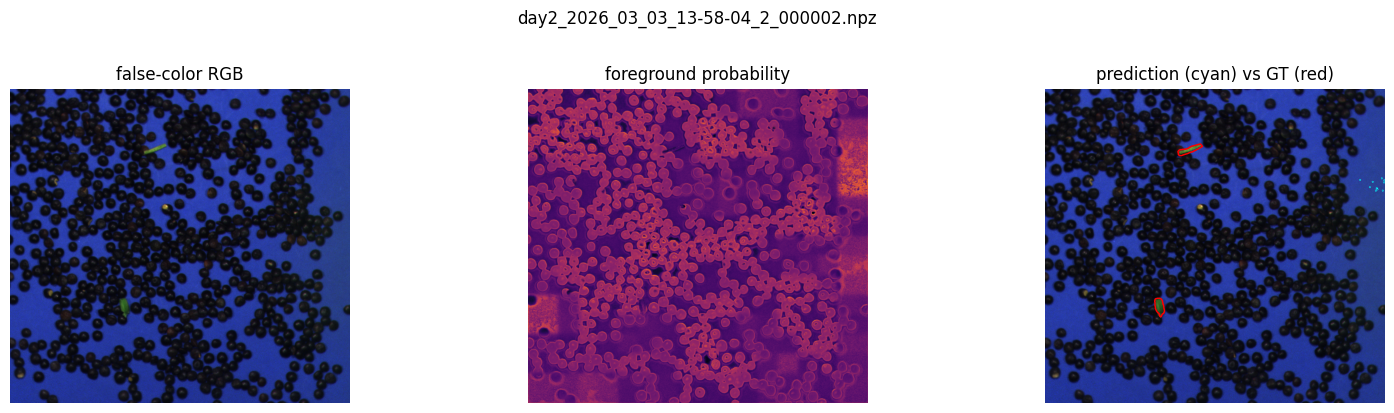

In [3]:
from pathlib import Path

import torch
from cuvis_ai_schemas.enums import ExecutionStage
from cuvis_ai_schemas.execution import Context


def predict_frame(pipeline, npz_path):
    """Full-frame tiled inference -> (fg_prob [H,W], pred_mask [H,W])."""
    nodes = {n.name: n for n in pipeline.nodes}
    norm, net = nodes["Norm"], nodes["DynUNet"]
    device = next(iter(net.parameters())).device
    frame = utils.load_lentils_frame(npz_path)
    cube = torch.from_numpy(frame["cube"]).unsqueeze(0).to(device)
    with torch.no_grad():
        normed = norm.forward(data=cube)["normalized"]
        ctx = Context(stage=ExecutionStage.INFERENCE, batch_idx=0, global_step=0)
        logits = net.forward(normed, context=ctx)["logits"][0]  # [H, W, K]
        fg_prob = torch.softmax(logits.float(), dim=-1)[..., 1].cpu().numpy()
        pred = (logits.argmax(-1) >= 1).cpu().numpy()
    return frame, fg_prob, pred


# pick the first object frames of the test split
test_frames = eng.split_frames(splits_csv, "test")
object_frames = objs[:3]  # reuse the mask-only classification from the eval cell
for p in object_frames:
    frame, fg_prob, pred = predict_frame(pipe, p)
    utils.render_segmentation_panel(
        frame["cube"], fg_prob, pred,
        wavelengths=frame["wavelengths"], gt_mask=frame["mask"],
        title=Path(p).name,
    )

## Going further

- `examples/lentils/profile_pipeline.py` sweeps `tile_overlap` × `tile_batch` with cuvis-ai's
  built-in per-node profiler.
- `tile_overlap=0` (with `tile_gaussian=false`) is a ~3.3× faster eval mode at ~1.5–2 %
  relative fg-IoU cost; with `tile_batch=16` the full-quality `0.5` overlap already runs at
  ~21 fps on an RTX 4090, so the trade-off is rarely needed.
- Data loading (~1 s per 263 MB compressed frame) dominates end-to-end throughput — see the
  known-limitations section of the README.